In [39]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy import optimize

https://stackoverflow.com/questions/75849031/solving-multiple-solution-equation-in-python/79842098#79842098

In [2]:
def equation(x, M, delta):
    return np.tan(M * x) * (1. + delta * np.cos(x)) + delta * np.sin(x)

In [14]:
p0s = [
    {"M": 1., "delta": 0.5},
    {"M": 1., "delta": 1.},
    {"M": 4., "delta": 0.5},
    {"M": 1., "delta": 3.1},
    {"M": 4., "delta": 3.1},
]

In [16]:
ymax = 10.

In [31]:
xlin = np.linspace(0., np.pi, 2000)

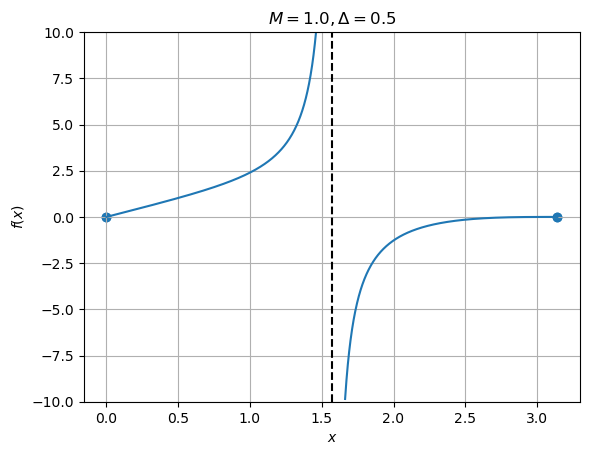

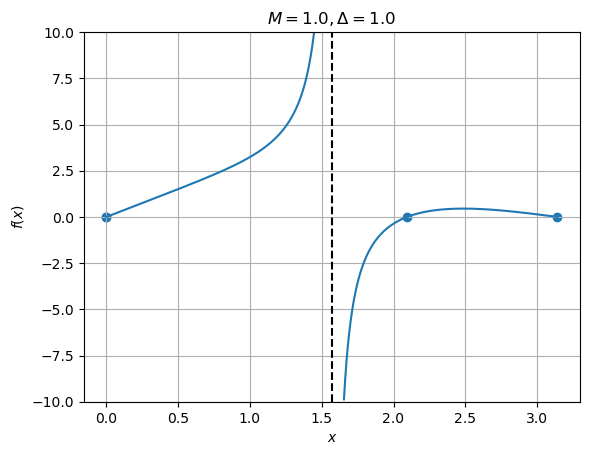

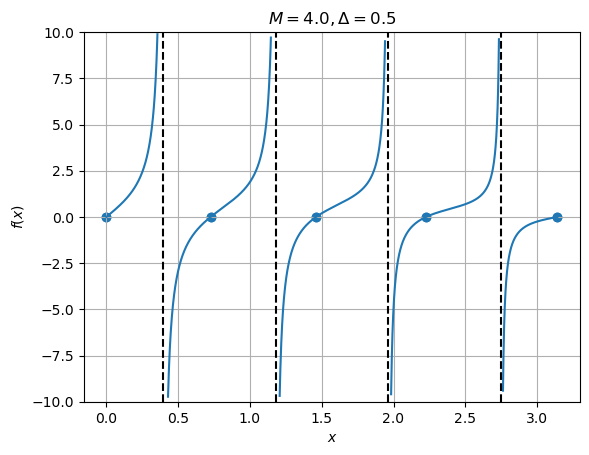

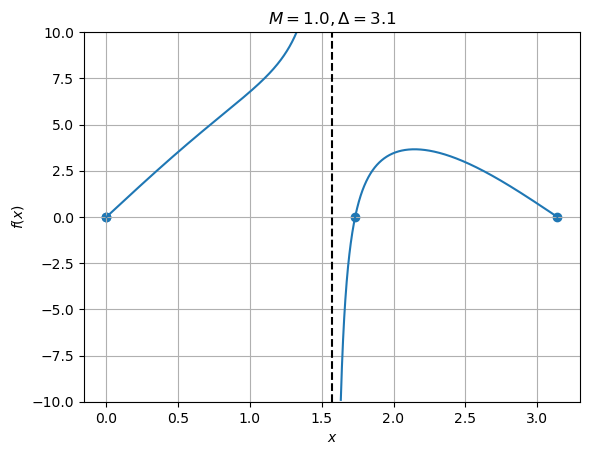

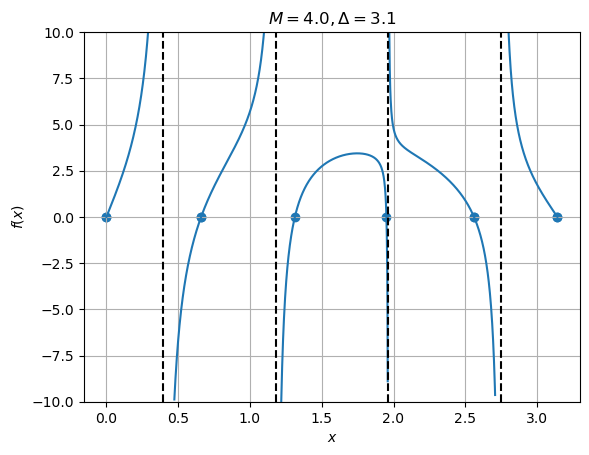

In [47]:
for p0 in p0s:
    
    flin = equation(xlin, **p0)
    flin[np.abs(flin)>ymax] = np.nan

    asymptotes = np.arange(-np.pi / (2 * p0['M']), np.pi, np.pi / (p0['M']))[1:]
    initial_guesses = [0.] + list(itertools.chain.from_iterable([(0.999 * x, 1.001 * x) for x in asymptotes])) + [np.pi]

    roots = []
    for initial_guess in initial_guesses:
        root = optimize.root(equation, x0=initial_guess, args=(p0['M'], p0['delta']))
        if root.success:
            roots.append(root.x)
    
    fig, axe = plt.subplots()
    axe.plot(xlin, flin)
    axe.scatter(roots, [0.] * len(roots))
    for asymptote in asymptotes:
        axe.axvline(asymptote, color="black", linestyle="--")
        
    axe.set_ylim([-ymax, ymax])
    axe.grid()
    axe.set_title(rf"$M={p0['M']}, \Delta={p0['delta']}$")
    axe.set_xlabel("$x$")
    axe.set_ylabel("$f(x)$")